## Extractig the Dataset

In [1]:
import os
import zipfile

# ==============================
# Step 1: Zip file path
# ==============================
zip_path = r"E:\Hira_ML_Unlearning\Machine Unlearning Sara Miss\Machine Unlearning\cifar100.zip"

# ==============================
# Step 2: Create extraction folder
# ==============================
foldername = os.path.splitext(os.path.basename(zip_path))[0]
foldername = foldername.replace(' ', '_').lower() + "_dataset"
extract_folder = os.path.join(os.path.dirname(zip_path), foldername)

os.makedirs(extract_folder, exist_ok=True)

# ==============================
# Step 3: Extract zip
# ==============================
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("✅ Dataset extracted to:", extract_folder)


✅ Dataset extracted to: E:\Hira_ML_Unlearning\Machine Unlearning Sara Miss\Machine Unlearning\cifar100_dataset


## The Path of Testing and Treaing 

In [2]:
import os

base_path = r"E:\Hira_ML_Unlearning\Machine Unlearning Sara Miss\Machine Unlearning"

# Find *_dataset folders
dataset_folders = [
    d for d in os.listdir(base_path)
    if d.endswith('_dataset') and os.path.isdir(os.path.join(base_path, d))
]

for folder in dataset_folders:
    dataset_path = os.path.join(base_path, folder)

    print(f"\n📁 Inspecting: {folder}")

    for root, dirs, files in os.walk(dataset_path):
        # Convert absolute path → relative path
        relative_root = os.path.relpath(root, base_path)
        print("📂", relative_root)

        for file in files[:5]:  # show only first 5 files
            print("   └──", file)



📁 Inspecting: cifar100_dataset
📂 cifar100_dataset
📂 cifar100_dataset\cifar100
📂 cifar100_dataset\cifar100\test
📂 cifar100_dataset\cifar100\test\apple
   └── apple-1014.png
   └── apple-1027.png
   └── apple-113.png
   └── apple-1136.png
   └── apple-1304.png
📂 cifar100_dataset\cifar100\test\aquarium_fish
   └── aquarium_fish-1017.png
   └── aquarium_fish-1082.png
   └── aquarium_fish-1108.png
   └── aquarium_fish-1110.png
   └── aquarium_fish-132.png
📂 cifar100_dataset\cifar100\test\baby
   └── baby-1012.png
   └── baby-1047.png
   └── baby-1152.png
   └── baby-1173.png
   └── baby-1479.png
📂 cifar100_dataset\cifar100\test\bear
   └── bear-1028.png
   └── bear-1055.png
   └── bear-1176.png
   └── bear-1300.png
   └── bear-1302.png
📂 cifar100_dataset\cifar100\test\beaver
   └── beaver-1105.png
   └── beaver-1312.png
   └── beaver-1379.png
   └── beaver-140.png
   └── beaver-1450.png
📂 cifar100_dataset\cifar100\test\bed
   └── bed-1142.png
   └── bed-1206.png
   └── bed-1219.png
   └── 

### Visulize the Number Classed , Teraining and Testing Sample

train_dir exists? True E:\Hira_ML_Unlearning\Machine Unlearning Sara Miss\Machine Unlearning\cifar100_dataset\cifar100\train
test_dir exists? True E:\Hira_ML_Unlearning\Machine Unlearning Sara Miss\Machine Unlearning\cifar100_dataset\cifar100\test
✅ Number of classes: 100
Training samples: 50000
Testing samples: 10000


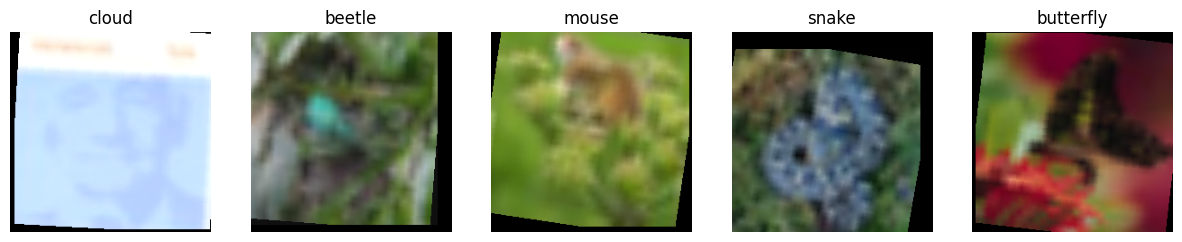

In [3]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

IMG_SIZE = 224
BATCH_SIZE = 16

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# ✅ Correct base dir (point to the extracted folder, NOT the zip)
base_dir = r"E:\Hira_ML_Unlearning\Machine Unlearning Sara Miss\Machine Unlearning\cifar100_dataset\cifar100"

# ✅ Correct folder names (train/test, not training/testing)
train_dir = os.path.join(base_dir, "train") 
test_dir  = os.path.join(base_dir, "test")

# ✅ Safety check (will tell you immediately if path is wrong)
print("train_dir exists?", os.path.exists(train_dir), train_dir)
print("test_dir exists?", os.path.exists(test_dir), test_dir)

# Load datasets
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_names = train_dataset.classes
print("✅ Number of classes:", len(class_names))
print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

# Visualize some images
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5) + 0.5  # unnormalize
    axes[i].imshow(img)
    axes[i].set_title(class_names[labels[i]])
    axes[i].axis("off")

plt.show()

## 1--Install Dependencise ===> for Runing the Deep Learning Algo


In [4]:
# Colab: install necessary libs
!pip install -q timm grad-cam scikit-learn



In [5]:
!python -m pip install --upgrade pip

## For Utilizing the GPU of Lab's PC

In [6]:
# ====================================
# ✅ FIX: Disable HuggingFace symlink warning
# ====================================
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

# ====================================
# 🚀 Imports & Setup
# ====================================
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import timm
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

from sklearn.metrics import confusion_matrix, classification_report

# ====================================
# 🔒 Reproducibility
# ====================================
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# ====================================
# ⚡ CUDA PERFORMANCE SETTINGS (IMPORTANT)
# ====================================
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.enabled = True

# ====================================
# ⚡ Device setup (GPU FIRST)
# ====================================
if not torch.cuda.is_available():
    raise RuntimeError("❌ CUDA NOT AVAILABLE — GPU CANNOT BE USED")

device = torch.device("cuda")
print("✅ CUDA available:", torch.cuda.is_available())
print("🚀 GPU:", torch.cuda.get_device_name(0))

# ====================================
# 🗂️ DATASET PATHS
# ====================================
# ====================================
# 🗂️ DATASET PATHS (FIXED)
# ====================================
base_dir = r"E:\Hira_ML_Unlearning\Machine Unlearning Sara Miss\Machine Unlearning\cifar100_dataset\cifar100"

train_dir = os.path.join(base_dir, "train")
test_dir  = os.path.join(base_dir, "test")

print("train_dir:", train_dir, "exists?", os.path.exists(train_dir))
print("test_dir :", test_dir,  "exists?", os.path.exists(test_dir))

IMG_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 4   # IMPORTANT for GPU pipeline

# ====================================
# 🧠 CoAtNet Model Data Config
# ====================================
model_name = "coatnet_0_rw_224"

tmp_model = timm.create_model(model_name, pretrained=True)
data_config = timm.data.resolve_model_data_config(tmp_model)
del tmp_model

# ====================================
# 🧩 Transforms
# ====================================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=data_config["mean"],
        std=data_config["std"]
    ),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=data_config["mean"],
        std=data_config["std"]
    ),
])

# ====================================
# 📦 Load Datasets
# ====================================
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=test_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("✅ Number of classes:", len(train_dataset.classes))
print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

# ====================================
# 🧠 CREATE MODEL (GPU ENABLED)
# ====================================
model = timm.create_model(
    model_name,
    pretrained=True,
    num_classes=len(train_dataset.classes)
)

model = model.to(device)  # 🚀 THIS ACTIVATES GPU

# ====================================
# 🔍 GPU VERIFICATION TEST
# ====================================
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
with torch.no_grad():
    _ = model(dummy)

print("🔥 MODEL SUCCESSFULLY RUNNING ON GPU")


✅ CUDA available: True
🚀 GPU: NVIDIA GeForce RTX 4070
train_dir: E:\Hira_ML_Unlearning\Machine Unlearning Sara Miss\Machine Unlearning\cifar100_dataset\cifar100\train exists? True
test_dir : E:\Hira_ML_Unlearning\Machine Unlearning Sara Miss\Machine Unlearning\cifar100_dataset\cifar100\test exists? True
✅ Number of classes: 100
Training samples: 50000
Testing samples: 10000
🔥 MODEL SUCCESSFULLY RUNNING ON GPU


## 🔥 Step 3: Build the ResNet-18 Teacher Model (For Knowledge Distillation)

In [7]:
import torch
import torch.nn as nn
import torchvision.models as models

# ====================================
# ⚡ Device setup (GPU)
# ====================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))



# ====================================
# 📌 Define number of classes (FIXED)
# ====================================
num_classes = len(train_dataset.classes)  # = 120

# ====================================
# 🧠 Load pretrained ResNet-18
# ====================================
teacher_model = models.resnet18(
    weights=models.ResNet18_Weights.IMAGENET1K_V1
)

# ====================================
# 🔁 Modify final layer (FIXED)
# ====================================
teacher_model.fc = nn.Linear(
    teacher_model.fc.in_features,
    num_classes
)

# ====================================
# 🚀 Move model to GPU
# ====================================
teacher_model = teacher_model.to(device)


# ====================================
# 🔍 GPU verification test
# ====================================
dummy = torch.randn(1, 3, 224, 224).to(device)
with torch.no_grad():
    _ = teacher_model(dummy)

print("🔥 ResNet-18 successfully running on GPU")


Using device: cuda
GPU: NVIDIA GeForce RTX 4070
🔥 ResNet-18 successfully running on GPU


## Step 3.2: Define Loss & Optimizer

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(teacher_model.parameters(), lr=1e-4)


## Step 3.3: Training Loop for Teacher Mode

In [9]:
from tqdm import tqdm

def train_teacher(model, train_loader, test_loader, epochs=30):
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        # Evaluate after each epoch
        acc = evaluate(model, test_loader)
        print(f"\nEpoch {epoch+1} → Loss: {running_loss/len(train_loader):.4f} | Test Accuracy: {acc:.2f}%\n")

    return model


# Step 3.4: Evaluation Function

In [10]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return 100 * correct / total


## Step 3.5: Train the Teacher Model

In [11]:
teacher_model = train_teacher(teacher_model, train_loader, test_loader, epochs=30)


Epoch 1/30: 100%|██████████████████████████████████████████████████████████████████| 3125/3125 [01:07<00:00, 46.13it/s]



Epoch 1 → Loss: 1.6044 | Test Accuracy: 72.59%



Epoch 2/30: 100%|██████████████████████████████████████████████████████████████████| 3125/3125 [01:03<00:00, 49.39it/s]



Epoch 2 → Loss: 0.8484 | Test Accuracy: 77.02%



Epoch 3/30: 100%|██████████████████████████████████████████████████████████████████| 3125/3125 [01:02<00:00, 49.85it/s]


...


Epoch 28 → Loss: 0.0570 | Test Accuracy: 76.69%



Epoch 29/30: 100%|█████████████████████████████████████████████████████████████████| 3125/3125 [01:02<00:00, 49.91it/s]



Epoch 29 → Loss: 0.0563 | Test Accuracy: 77.56%



Epoch 30/30: 100%|█████████████████████████████████████████████████████████████████| 3125/3125 [01:02<00:00, 50.07it/s]



Epoch 30 → Loss: 0.0530 | Test Accuracy: 77.87%



# 🔹 Step 4.1 — Choose forget class & set random seed

In [51]:
# ====================================
# 🔹 Step 4.1 — Randomly select 15 classes to forget
# ====================================

import random
import numpy as np
import torch

# ------------------------------------
# Reproducibility
# ------------------------------------
RND_SEED = 42
random.seed(RND_SEED)
np.random.seed(RND_SEED)
torch.manual_seed(RND_SEED)

# ------------------------------------
# Get class names from dataset
# ------------------------------------
class_names = train_dataset.classes   # already loaded earlier
num_classes = len(class_names)

print("✅ Total classes:", num_classes)

# ------------------------------------
# Randomly choose 10 classes to forget
# ------------------------------------
NUM_FORGET_CLASSES = 10

forget_classes = random.sample(class_names, NUM_FORGET_CLASSES)

# ------------------------------------
# Get class indices (VERY IMPORTANT)
# ------------------------------------
forget_class_indices = [
    class_names.index(cls) for cls in forget_classes
]

# ------------------------------------
# Display results
# ------------------------------------
print("\n🔥 RANDOMLY SELECTED FORGET CLASSES 🔥")
for cls, idx in zip(forget_classes, forget_class_indices):
    print(f"  - Class name: {cls} | Class index: {idx}")

# ------------------------------------
# Safety check
# ------------------------------------
assert len(forget_classes) == NUM_FORGET_CLASSES
assert all(idx < num_classes for idx in forget_class_indices)

print("\n✅ Step 4.1 completed successfully")


✅ Total classes: 100

🔥 RANDOMLY SELECTED FORGET CLASSES 🔥
  - Class name: streetcar | Class index: 81
  - Class name: butterfly | Class index: 14
  - Class name: bear | Class index: 3
  - Class name: wardrobe | Class index: 94
  - Class name: girl | Class index: 35
  - Class name: elephant | Class index: 31
  - Class name: cup | Class index: 28
  - Class name: castle | Class index: 17
  - Class name: bus | Class index: 13
  - Class name: telephone | Class index: 86

✅ Step 4.1 completed successfully


## 🔹 Step 4.2 — Get label index for the forget class and list indices

In [52]:
# ====================================
# 🔹 Step 4.2 — Build FORGET / KEEP indices (MULTI-CLASS)
# ====================================

from collections import defaultdict

# ------------------------------------
# ImageFolder mapping
# ------------------------------------
class_to_idx = train_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

print("✅ Total classes in mapping:", len(class_to_idx))

# ------------------------------------
# Sanity check: all forget classes exist
# ------------------------------------
for cls in forget_classes:
    if cls not in class_to_idx:
        raise ValueError(f"❌ Forget class '{cls}' not found in dataset")

# ------------------------------------
# Get numeric labels of forget classes
# ------------------------------------
forget_labels = [class_to_idx[cls] for cls in forget_classes]

print("\n🔥 Forget class labels:")
for cls, lbl in zip(forget_classes, forget_labels):
    print(f"  - {cls} → label {lbl}")

# ------------------------------------
# Collect dataset indices
# ------------------------------------
forget_indices = []
keep_indices = []

for idx, (_, label) in enumerate(train_dataset):
    if label in forget_labels:
        forget_indices.append(idx)
    else:
        keep_indices.append(idx)

# ------------------------------------
# Summary
# ------------------------------------
print("\n📊 DATASET SPLIT SUMMARY")
print(f"Total training samples : {len(train_dataset)}")
print(f"Samples to forget      : {len(forget_indices)}")
print(f"Samples to keep        : {len(keep_indices)}")

# ------------------------------------
# Safety checks
# ------------------------------------
assert len(forget_indices) + len(keep_indices) == len(train_dataset)
assert len(set(forget_indices).intersection(set(keep_indices))) == 0

print("\n✅ Step 4.2 completed successfully")


✅ Total classes in mapping: 100

🔥 Forget class labels:
  - streetcar → label 81
  - butterfly → label 14
  - bear → label 3
  - wardrobe → label 94
  - girl → label 35
  - elephant → label 31
  - cup → label 28
  - castle → label 17
  - bus → label 13
  - telephone → label 86

📊 DATASET SPLIT SUMMARY
Total training samples : 50000
Samples to forget      : 5000
Samples to keep        : 45000

✅ Step 4.2 completed successfully


## 🔹 Step 4.3 — Create Subset datasets and DataLoaders (keep / forget)

In [53]:
# Step 4.3 — Create Subset datasets & loaders
from torch.utils.data import Subset, DataLoader

# Subsets
forget_dataset = Subset(train_dataset, forget_indices)  # only the class we will forget
keep_dataset   = Subset(train_dataset, keep_indices)    # all other classes

# Dataloaders
keep_loader = DataLoader(keep_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
forget_loader = DataLoader(forget_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Keep dataset size:", len(keep_dataset))
print("Forget dataset size:", len(forget_dataset))


Keep dataset size: 45000
Forget dataset size: 5000


## 🔹 Step 4.4 — Create a test-only loader for the forgotten class (for evaluation)

In [54]:
# ====================================
# 🔹 Step 4.4 — Test loader for FORGOTTEN classes (MULTI-CLASS)
# ====================================

from torch.utils.data import Subset, DataLoader

# ------------------------------------
# Collect test indices belonging to forgotten classes
# ------------------------------------
test_forget_indices = [
    i for i, (_, label) in enumerate(test_dataset)
    if label in forget_labels
]

# ------------------------------------
# Create subset & loader
# ------------------------------------
test_forget_dataset = Subset(test_dataset, test_forget_indices)

test_forget_loader = DataLoader(
    test_forget_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# ------------------------------------
# Summary
# ------------------------------------
print("📊 TEST FORGET SET SUMMARY")
print(f"Total test samples           : {len(test_dataset)}")
print(f"Test samples to be forgotten : {len(test_forget_dataset)}")

print("\n🔥 Forgotten classes in test set:")
for cls, lbl in zip(forget_classes, forget_labels):
    print(f"  - {cls} → label {lbl}")

print("\n✅ Step 4.4 completed successfully")


📊 TEST FORGET SET SUMMARY
Total test samples           : 10000
Test samples to be forgotten : 1000

🔥 Forgotten classes in test set:
  - streetcar → label 81
  - butterfly → label 14
  - bear → label 3
  - wardrobe → label 94
  - girl → label 35
  - elephant → label 31
  - cup → label 28
  - castle → label 17
  - bus → label 13
  - telephone → label 86

✅ Step 4.4 completed successfully


## 🔹 Step 4.5 — (Optional but recommended) Inspect a few images from the forget set

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9137255].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.99215686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.8509804].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.7411765].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9137255..0.8745098].


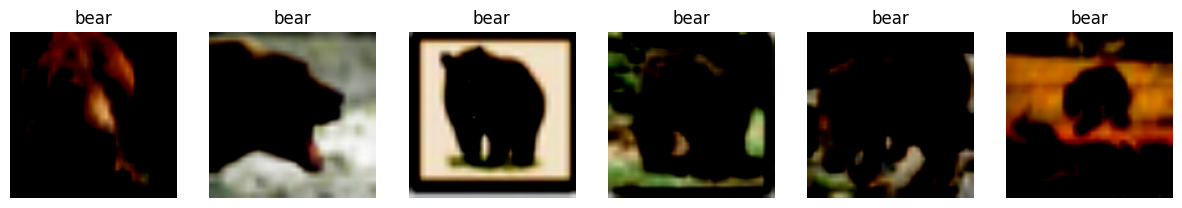

In [55]:
# Step 4.5 — Visualize a few sample images from the forgotten class so you know what will be removed
import matplotlib.pyplot as plt

def imshow_tensor(img_tensor, title=None):
    # img_tensor is normalized; convert to displayable format
    img = img_tensor.clone().cpu()
    # if single-channel normalized with mean=0.5 std=0.5 from your earlier transform:
    # img = img * 0.5 + 0.5
    img = img.permute(1, 2, 0).numpy()  # CHW -> HWC
    # if grayscale converted to 3 channels, image still displays fine
    plt.imshow(img.squeeze(), cmap='gray')
    if title: plt.title(title)
    plt.axis('off')

# take first batch from forget_loader
batch = next(iter(forget_loader))
imgs, labels = batch
N = min(6, imgs.size(0))
plt.figure(figsize=(15, 4))
for i in range(N):
    plt.subplot(1, N, i+1)
    class_name = train_dataset.classes[labels[i].item()]
    imshow_tensor(imgs[i], title=f"{class_name}")
plt.show()


## 🔹 Step 4.6 — Save the forget / keep indices (optional, reproducible)

In [56]:
# ====================================
# 🔹 Step 4.6 — Save unlearning split (MULTI-CLASS)
# ====================================
import json

save_info = {
    "forget_classes": forget_classes,                  # list of class names
    "forget_labels": [int(l) for l in forget_labels],  # list of labels
    "forget_indices": forget_indices,
    "keep_indices": keep_indices
}

with open("unlearning_indices.json", "w") as f:
    json.dump(save_info, f, indent=4)

print("✅ Saved unlearning indices to 'unlearning_indices.json'")


✅ Saved unlearning indices to 'unlearning_indices.json'


## 🔹 Step 4.7 — Quick sanity-check: tiny evaluation on keep vs teacher model

In [57]:
# Step 4.7 — Sanity check: run teacher model on a small batch from keep_loader and forget_loader
# (Assumes teacher_model exists from Step 3)
teacher_model.eval()
with torch.no_grad():
    keep_imgs, keep_lbls = next(iter(keep_loader))
    f_imgs, f_lbls = next(iter(forget_loader))
    out_keep = teacher_model(keep_imgs.to(device))
    out_f    = teacher_model(f_imgs.to(device))
    # compute avg max-confidence
    import torch.nn.functional as F
    keep_conf = F.softmax(out_keep, dim=1).max(dim=1)[0].mean().item()
    f_conf    = F.softmax(out_f, dim=1).max(dim=1)[0].mean().item()

print(f"Teacher avg max-confidence on kept-samples batch: {keep_conf:.4f}")
print(f"Teacher avg max-confidence on forgotten-class batch: {f_conf:.4f}")


Teacher avg max-confidence on kept-samples batch: 0.9951
Teacher avg max-confidence on forgotten-class batch: 0.9935


## 🔹 Step 5.1 — Build student ResNet-18 (fresh init) & helper to create model

In [58]:
# Step 5.1 — Build student ResNet-18 (option for pretrained)
import torch
import torch.nn as nn
import torchvision.models as models

def get_resnet18_student(num_classes, pretrained=False):
    if pretrained:
        student = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    else:
        student = models.resnet18(weights=None)  # TRAIN FROM SCRATCH

    student.fc = nn.Linear(student.fc.in_features, num_classes)
    return student.to(device)

# Choose pretrained=True ONLY if you're doing Step B
num_classes = len(class_names)
student_model = get_resnet18_student(num_classes, pretrained=False)
print("Student model created. Pretrained:", False)


Student model created. Pretrained: False


## 🔹 Step 5.2 — Define KD (distillation) loss and optimizer

In [59]:
# 🔹 Step 5.2 — Distillation loss (soft + hard) + Optimizer

import torch.nn.functional as F
import torch.optim as optim

def distillation_loss(student_logits, teacher_logits, labels, T=3.0, alpha=0.5):
    """
    student_logits, teacher_logits: raw logits (no softmax)
    labels: hard labels (integers)
    T: temperature
    alpha: weighting for soft (teacher) loss
           final loss = alpha * soft_loss + (1-alpha) * hard_loss
    """

    # Soft target loss (KL-divergence)
    log_p = F.log_softmax(student_logits / T, dim=1)
    q = F.softmax(teacher_logits / T, dim=1)

    soft_loss = F.kl_div(log_p, q, reduction='batchmean') * (T * T)

    # Hard target loss (cross-entropy vs ground truth)
    hard_loss = F.cross_entropy(student_logits, labels)

    # Final KD loss
    return alpha * soft_loss + (1 - alpha) * hard_loss


# ✅ Correct optimizer creation (FIX)
student_optimizer = optim.Adam(student_model.parameters(), lr=3e-4)

print("✅ KD loss function ready")
print("✅ Optimizer ready: Adam(lr=3e-4)")


✅ KD loss function ready
✅ Optimizer ready: Adam(lr=3e-4)


## 🔹 Step 5.3 — Student training loop (Knowledge Distillation on keep_loader)

In [60]:
# Step 5.3 — Train student with KD
from tqdm import tqdm

def train_student_kd(student, teacher, keep_loader, epochs=5, T=3.0, alpha=0.7):
    teacher.eval()   # freeze teacher
    for epoch in range(epochs):
        student.train()
        running_loss = 0.0
        pbar = tqdm(keep_loader, desc=f"KD Epoch {epoch+1}/{epochs}", leave=False)
        for imgs, labels in pbar:
            imgs, labels = imgs.to(device), labels.to(device)

            # teacher logits (no grad)
            with torch.no_grad():
                teacher_logits = teacher(imgs)

            student_optimizer.zero_grad()
            student_logits = student(imgs)

            loss = distillation_loss(student_logits, teacher_logits, labels, T=T, alpha=alpha)
            loss.backward()
            student_optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(keep_loader)
        # quick evaluation of student on test set after each epoch
        acc = evaluate(student, test_loader)
        print(f"Epoch {epoch+1}/{epochs} — KD Loss: {avg_loss:.4f} | Test Acc: {acc:.2f}%")

    return student

# Hyperparams: you can tune T and alpha
EPOCHS_UNLEARN = 30
TEMP = 4.0
ALPHA = 0.7

student_model = train_student_kd(student_model, teacher_model, keep_loader,
                                 epochs=EPOCHS_UNLEARN, T=TEMP, alpha=ALPHA)


Epoch 1/30 — KD Loss: 26.7015 | Test Acc: 18.57%


Epoch 2/30 — KD Loss: 21.0066 | Test Acc: 30.85%


Epoch 3/30 — KD Loss: 16.4659 | Test Acc: 42.00%


Epoch 4/30 — KD Loss: 13.6187 | Test Acc: 45.97%


Epoch 5/30 — KD Loss: 11.7178 | Test Acc: 49.74%


...

Epoch 26/30 — KD Loss: 1.8836 | Test Acc: 64.31%


Epoch 27/30 — KD Loss: 1.8334 | Test Acc: 64.17%


Epoch 28/30 — KD Loss: 1.7673 | Test Acc: 64.70%


Epoch 29/30 — KD Loss: 1.7007 | Test Acc: 64.63%


Epoch 30/30 — KD Loss: 1.6615 | Test Acc: 64.37%


## 🔹 Step 5.4 — Evaluate student: classification report on full test set

In [61]:
# Step 5.4 — Full test set classification report for the student model
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get predictions
student_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = student_model(imgs)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Classification Report — Student (After Unlearning):\n")
print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))


Classification Report — Student (After Unlearning):

               precision    recall  f1-score   support

        apple       0.87      0.92      0.89       100
aquarium_fish       0.86      0.83      0.85       100
         baby       0.60      0.68      0.64       100
         bear       1.00      0.02      0.04       100
       beaver       0.38      0.74      0.50       100
          bed       0.74      0.73      0.74       100
          bee       0.78      0.72      0.75       100
       beetle       0.78      0.67      0.72       100
      bicycle       0.96      0.82      0.89       100
       bottle       0.67      0.89      0.76       100
         bowl       0.41      0.60      0.49       100
          boy       0.41      0.50      0.45       100
       bridge       0.68      0.81      0.74       100
          bus       1.00      0.01      0.02       100
    butterfly       1.00      0.01      0.02       100
        camel       0.59      0.73      0.65       100
          c

In [62]:
from sklearn.metrics import classification_report
import numpy as np

forget_labels = forget_labels  # list of labels you already have
forget_names = [class_names[l] for l in forget_labels]

# Filter test predictions
mask = np.isin(all_labels, forget_labels)
filtered_labels = np.array(all_labels)[mask]
filtered_preds  = np.array(all_preds)[mask]

print("Classification Report — Forgotten Classes Only:\n")
print(classification_report(
    filtered_labels,
    filtered_preds,
    labels=forget_labels,
    target_names=forget_names,
    zero_division=0
))


Classification Report — Forgotten Classes Only:

              precision    recall  f1-score   support

   streetcar       0.00      0.00      0.00       100
   butterfly       1.00      0.01      0.02       100
        bear       1.00      0.02      0.04       100
    wardrobe       1.00      0.06      0.11       100
        girl       1.00      0.01      0.02       100
    elephant       0.00      0.00      0.00       100
         cup       0.00      0.00      0.00       100
      castle       0.00      0.00      0.00       100
         bus       1.00      0.01      0.02       100
   telephone       0.00      0.00      0.00       100

   micro avg       1.00      0.01      0.02      1000
   macro avg       0.50      0.01      0.02      1000
weighted avg       0.50      0.01      0.02      1000



## Confussion Matrix of Forgotten Class

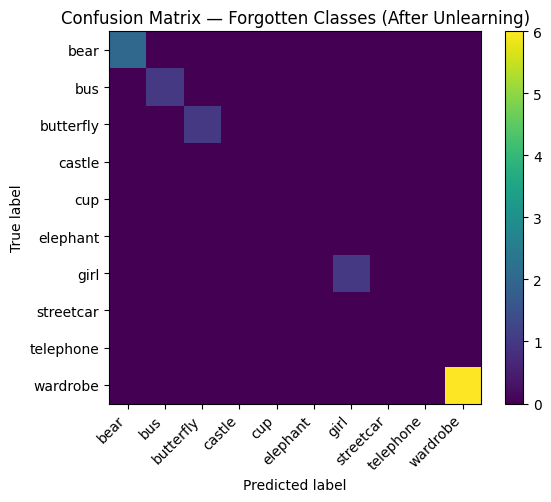

In [63]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

forget_labels = sorted(forget_labels)
forget_names = [class_names[l] for l in forget_labels]

# Filter predictions
all_labels_np = np.array(all_labels)
all_preds_np  = np.array(all_preds)

mask = np.isin(all_labels_np, forget_labels)

y_true = all_labels_np[mask]
y_pred = all_preds_np[mask]

cm = confusion_matrix(y_true, y_pred, labels=forget_labels)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(forget_names)), forget_names, rotation=45, ha="right")
plt.yticks(range(len(forget_names)), forget_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix — Forgotten Classes (After Unlearning)")
plt.tight_layout()
plt.show()


## 🔹 Step 5.5 — Evaluate student specifically on forgotten-class test set (test_forget_loader)

In [64]:
# Step 5.5 — Evaluate only on forgotten-class test samples
student_model.eval()
f_labels, f_preds = [], []
with torch.no_grad():
    for imgs, labels in test_forget_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = student_model(imgs)
        preds = torch.argmax(outputs, dim=1)
        f_preds.extend(preds.cpu().numpy())
        f_labels.extend(labels.cpu().numpy())

from sklearn.metrics import accuracy_score
if len(f_labels) > 0:
    acc_forgotten = accuracy_score(f_labels, f_preds) * 100
    print(f"Student accuracy on forgotten-class test samples: {acc_forgotten:.2f}% ({len(f_labels)} samples)")
else:
    print("No forgotten-class samples in test set (test_forget_loader empty).")


Student accuracy on forgotten-class test samples: 1.10% (1000 samples)


## 🔹 Step 5.6 — Membership-Inference style confidence comparison (Teacher vs Student)


In [65]:
# Step 5.6 — Compare average softmax confidence on forgotten samples (teacher vs student)
import torch.nn.functional as F
import numpy as np

def avg_confidence(model, loader):
    model.eval()
    confs = []
    with torch.no_grad():
        for imgs, _ in loader:
            imgs = imgs.to(device)
            logits = model(imgs)
            probs = F.softmax(logits, dim=1)
            max_conf, _ = probs.max(dim=1)
            confs.extend(max_conf.cpu().numpy().tolist())
    return float(np.mean(confs)), float(np.std(confs))

mean_teach_f, std_teach_f = avg_confidence(teacher_model, test_forget_loader)
mean_student_f, std_student_f = avg_confidence(student_model, test_forget_loader)

print("Teacher mean confidence on forgotten test samples  :", f"{mean_teach_f:.4f} ± {std_teach_f:.4f}")
print("Student mean confidence on forgotten test samples  :", f"{mean_student_f:.4f} ± {std_student_f:.4f}")


Teacher mean confidence on forgotten test samples  : 0.9122 ± 0.1680
Student mean confidence on forgotten test samples  : 0.8147 ± 0.2107


## 🔹 Step 5.7 — Save the student model & training metadata

In [66]:
# Step 5.7 — Save student model and metadata
import json
import torch

# Save model weights
torch.save(student_model.state_dict(), "student_resnet18_unlearned.pth")

# Save metadata
metadata = {
    "forget_labels": forget_labels,          # list of class indices
    "forget_names": forget_names,            # list of class names
    "num_epochs_student": EPOCHS_UNLEARN,
    "temperature": TEMP,
    "alpha": ALPHA,
    "student_accuracy_on_forgotten": acc_forgotten,
    "teacher_mean_confidence_forgotten": mean_teach_f,
    "student_mean_confidence_forgotten": mean_student_f
}

with open("student_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("Saved student model to student_resnet18_unlearned.pth")
print("Saved metadata to student_metadata.json")


Saved student model to student_resnet18_unlearned.pth
Saved metadata to student_metadata.json


## 🔹 Step 6.1 — Logit-distance between Teacher & Student on forget samples

In [67]:
# Step 6.1 — Logit distance between teacher & student
import torch
import torch.nn.functional as F
import numpy as np

teacher_model.eval()
student_model.eval()

logit_distances = []

with torch.no_grad():
    for imgs, _ in test_forget_loader:
        imgs = imgs.to(device)
        t_logits = teacher_model(imgs)
        s_logits = student_model(imgs)
        dist = F.mse_loss(s_logits, t_logits, reduction='none').mean(dim=1)
        logit_distances.extend(dist.cpu().numpy())

logit_distances = np.array(logit_distances)

print("🔍 Logit MSE Distance on forgotten samples")
print(f"Mean  : {logit_distances.mean():.4f}")
print(f"Std   : {logit_distances.std():.4f}")
print(f"Min   : {logit_distances.min():.4f}")
print(f"Max   : {logit_distances.max():.4f}")


🔍 Logit MSE Distance on forgotten samples
Mean  : 28.9399
Std   : 17.5072
Min   : 4.6786
Max   : 144.1541


## 🔹 Step 6.2 — Feature similarity (cosine) between teacher & student

In [68]:
# Step 6.2 — Extract penultimate layer features (teacher vs student)

from torch import nn

# Helper to capture features
def get_feature_extractor(model):
    layers = list(model.children())[:-1]   # all except the final FC
    return nn.Sequential(*layers)

teacher_feat = get_feature_extractor(teacher_model).eval()
student_feat = get_feature_extractor(student_model).eval()

cos_sims = []

with torch.no_grad():
    for imgs, _ in test_forget_loader:
        imgs = imgs.to(device)
        ft_t = teacher_feat(imgs).squeeze()
        ft_s = student_feat(imgs).squeeze()

        # flatten
        ft_t = ft_t.view(ft_t.size(0), -1)
        ft_s = ft_s.view(ft_s.size(0), -1)

        cos = F.cosine_similarity(ft_t, ft_s, dim=1)
        cos_sims.extend(cos.cpu().numpy())

cos_sims = np.array(cos_sims)

print("\n🔍 Feature Cosine Similarity (teacher vs student) on forgotten samples")
print(f"Mean  : {cos_sims.mean():.4f}")
print(f"Std   : {cos_sims.std():.4f}")
print(f"Min   : {cos_sims.min():.4f}")
print(f"Max   : {cos_sims.max():.4f}")



🔍 Feature Cosine Similarity (teacher vs student) on forgotten samples
Mean  : 0.6489
Std   : 0.0536
Min   : 0.4512
Max   : 0.8226


## 🔹 Step 6.3 — Confusion matrix for forgotten samples only

In [69]:
# Step 6.3 — Confusion matrix for the forgotten class

from sklearn.metrics import confusion_matrix
import numpy as np

student_model.eval()

true_labels = []
pred_labels = []

with torch.no_grad():
    for imgs, labels in test_forget_loader:
        imgs = imgs.to(device)
        outputs = student_model(imgs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        true_labels.extend(labels.numpy())
        pred_labels.extend(preds)

cm = confusion_matrix(true_labels, pred_labels)

print("\n🔍 Confusion Matrix on Forgotten Class Samples:\n")
print(cm)
print("\nNote: Rows = true labels (forgotten). Columns = predicted classes.")



🔍 Confusion Matrix on Forgotten Class Samples:

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 2 ... 2 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

Note: Rows = true labels (forgotten). Columns = predicted classes.


## 🔹 Step 6.4 — Randomness check (is student ≈ random on forgotten class?)
#### ---> Let’s verify more clearly using entropy of predictions: High entropy ≈ random → successful forgetting.

In [70]:
# Step 6.4 — Prediction entropy check (randomness test)

def prediction_entropy(probs):
    return -torch.sum(probs * torch.log(probs + 1e-9), dim=1)

student_model.eval()
entropies = []

with torch.no_grad():
    for imgs, _ in test_forget_loader:
        imgs = imgs.to(device)
        logits = student_model(imgs)
        probs = F.softmax(logits, dim=1)
        H = prediction_entropy(probs)
        entropies.extend(H.cpu().numpy())

entropies = np.array(entropies)

print("\n🔍 Entropy of predictions on forgotten samples")
print(f"Mean entropy: {entropies.mean():.4f}")
print(f"Max entropy : {entropies.max():.4f}")
print(f"Min entropy : {entropies.min():.4f}")

# Random guess entropy for C classes:
C = len(class_names)
H_random = np.log(C)
print(f"\nEntropy of uniform random prediction (ideal forgetting): {H_random:.4f}")



🔍 Entropy of predictions on forgotten samples
Mean entropy: 0.5407
Max entropy : 2.6077
Min entropy : 0.0000

Entropy of uniform random prediction (ideal forgetting): 4.6052


## 🔹 Step 7.1 — Install / import utilities (Colab cell)

In [71]:
  # Step 7.1 — Imports for Grad-CAM and visualization
  import torch
  import torch.nn.functional as F
  import numpy as np
  import matplotlib.pyplot as plt
  from PIL import Image
  import cv2


## 🔹 Step 7.2 — Helper: get target convolutional layer

In [72]:
# Step 7.2 — specify which conv layer to use for Grad-CAM
# For ResNet-18, use layer4 (last convolutional block)
teacher_target_layer = teacher_model.layer4
student_target_layer = student_model.layer4

print("Using ResNet layer4 for Grad-CAM.")


Using ResNet layer4 for Grad-CAM.


## 🔹 Step 7.3 — Grad-CAM implementation (hooks)

In [73]:
# Step 7.3 — Grad-CAM functions (works for both teacher & student)

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model.eval()
        self.device = next(model.parameters()).device

        self.activations = None
        self.gradients = None

        # register forward hook on target layer to capture activations
        def forward_hook(module, input, output):
            self.activations = output.detach()

        # register backward hook to capture gradients wrt activations
        def backward_hook(module, grad_in, grad_out):
            # grad_out is a tuple; take the first element
            self.gradients = grad_out[0].detach()

        target_layer.register_forward_hook(forward_hook)
        target_layer.register_full_backward_hook(backward_hook)

    def __call__(self, input_tensor, class_idx=None):
        """
        input_tensor: shape [1, C, H, W], already preprocessed and on correct device
        class_idx: target class index for which to produce Grad-CAM. If None, use predicted class.
        returns: heatmap (H, W) normalized [0..1]
        """
        self.model.zero_grad()
        output = self.model(input_tensor)  # forward
        if class_idx is None:
            class_idx = int(output.argmax(dim=1).item())

        score = output[0, class_idx]
        score.backward(retain_graph=True)

        # activations: [1, C, h, w], gradients: [1, C, h, w]
        grads = self.gradients  # [1,C,h,w]
        acts = self.activations  # [1,C,h,w]

        # global-average-pool gradients over spatial dims
        weights = grads.mean(dim=(2,3), keepdim=True)  # [1,C,1,1]
        # weighted combination
        gcam = (weights * acts).sum(dim=1, keepdim=True)  # [1,1,h,w]
        gcam = F.relu(gcam)  # ReLU
        gcam = gcam.squeeze().cpu().numpy()  # [h,w]

        # normalize to [0,1]
        gcam -= gcam.min()
        if gcam.max() != 0:
            gcam /= gcam.max()
        return gcam


## 🔹 Step 7.4 — Helper: preprocess & de-normalize image for display

In [74]:
# Step 7.4 — preprocessing helpers (use same transforms you used for training)
from torchvision import transforms

# If you trained teacher with ImageNet normalization (pretrained teacher), use ImageNet stats.
IMAGENET_NORM = True  # set False if you used mean=0.5/std=0.5

if IMAGENET_NORM:
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
else:
    mean = [0.5, 0.5, 0.5]
    std  = [0.5, 0.5, 0.5]

def denormalize_tensor(tensor):
    # tensor shape [C,H,W], CPU
    t = tensor.clone().cpu()
    for c in range(3):
        t[c] = t[c] * std[c] + mean[c]
    t = t.numpy().transpose(1,2,0)
    t = np.clip(t, 0, 1)
    return (t * 255).astype(np.uint8)

def overlay_heatmap_on_image(img_np, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    # img_np: H,W,3 uint8
    # heatmap: H,W float in [0,1]
    hmap = (heatmap * 255).astype(np.uint8)
    hmap_color = cv2.applyColorMap(hmap, colormap)  # BGR
    hmap_color = cv2.cvtColor(hmap_color, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_np.astype(np.float32), 1-alpha, hmap_color.astype(np.float32), alpha, 0)
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)
    return overlay


## 🔹 Step 7.5 — Pick a few forgotten-class test images (or any images) and run Grad-CAM

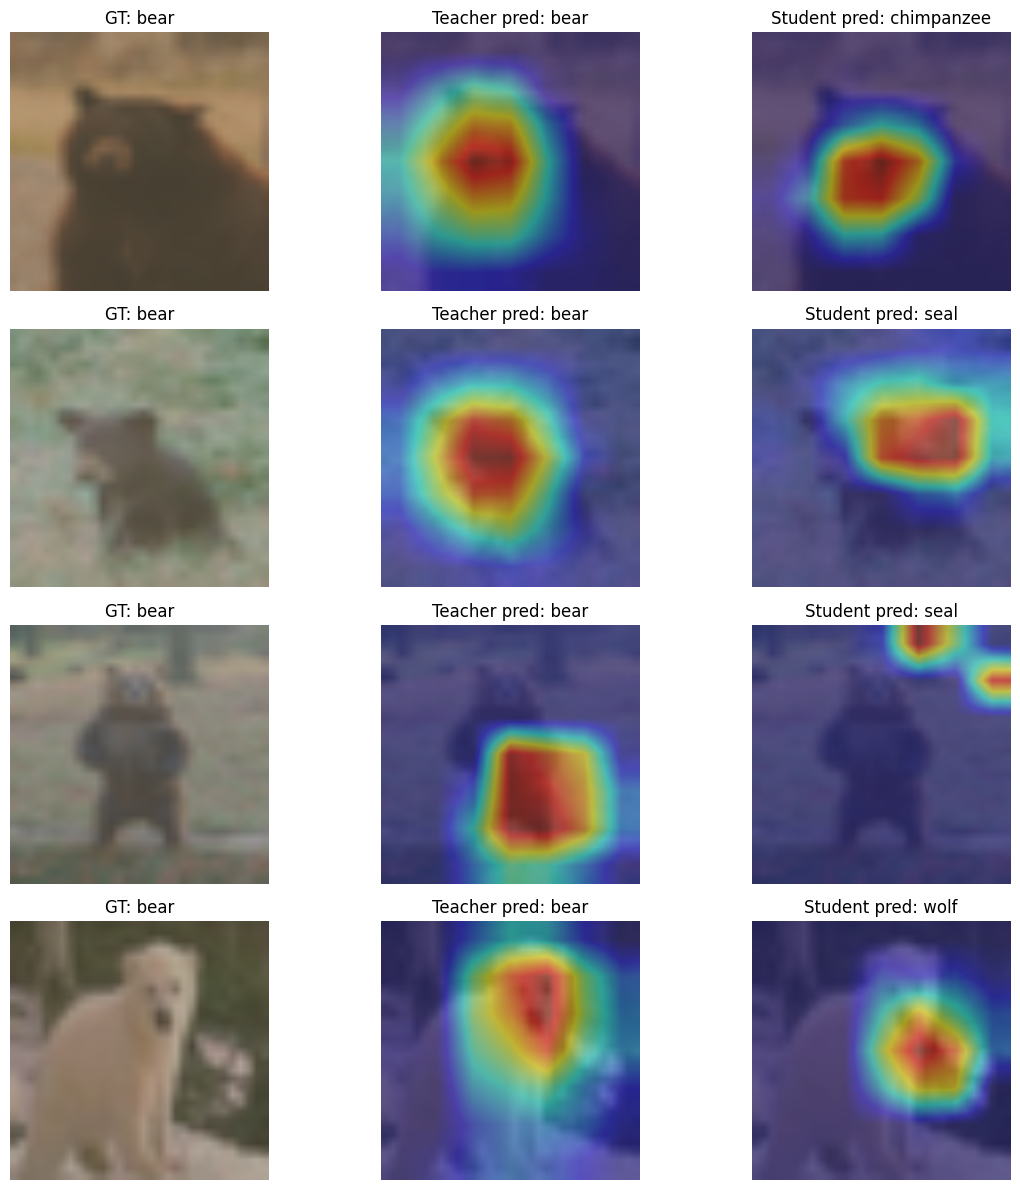

In [75]:
# Step 7.5 — Run Grad-CAM on N samples from test_forget_loader
N = 4  # number of examples to visualize
gcam_teacher = GradCAM(teacher_model, teacher_target_layer)
gcam_student = GradCAM(student_model, student_target_layer)

samples = []
# gather N images and their labels from test_forget_loader
for imgs, labels in test_forget_loader:
    for i in range(imgs.size(0)):
        samples.append((imgs[i], labels[i].item()))
        if len(samples) >= N:
            break
    if len(samples) >= N:
        break

# visualize each sample: original, teacher heatmap, student heatmap, overlays
plt.figure(figsize=(12, 3 * N))
for i, (img_tensor, label) in enumerate(samples):
    inp = img_tensor.unsqueeze(0).to(device)  # [1,C,H,W]
    # Grad-CAM for teacher (target teacher predicted class by default)
    heat_t = gcam_teacher(inp, class_idx=None)
    pred_t = int(teacher_model(inp).argmax(dim=1).item())

    # Grad-CAM for student
    heat_s = gcam_student(inp, class_idx=None)
    pred_s = int(student_model(inp).argmax(dim=1).item())

    # de-normalize for display
    img_np = denormalize_tensor(img_tensor)

    # resize heatmaps to image size if needed
    heat_t_resized = cv2.resize(heat_t, (img_np.shape[1], img_np.shape[0]))
    heat_s_resized = cv2.resize(heat_s, (img_np.shape[1], img_np.shape[0]))

    overlay_t = overlay_heatmap_on_image(img_np, heat_t_resized, alpha=0.45)
    overlay_s = overlay_heatmap_on_image(img_np, heat_s_resized, alpha=0.45)

    # Row: original, teacher overlay (pred label), student overlay (pred label)
    plt.subplot(N, 3, i*3 + 1)
    plt.imshow(img_np)
    plt.title(f"GT: {class_names[label]}")
    plt.axis('off')

    plt.subplot(N, 3, i*3 + 2)
    plt.imshow(overlay_t)
    plt.title(f"Teacher pred: {class_names[pred_t]}")
    plt.axis('off')

    plt.subplot(N, 3, i*3 + 3)
    plt.imshow(overlay_s)
    plt.title(f"Student pred: {class_names[pred_s]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


## 🔹 Step 7.6 — (Optional) Save visualization images

In [76]:
# Step 7.6 — Save each overlay image to disk
OUT_DIR = "gradcam_outputs"
import os
os.makedirs(OUT_DIR, exist_ok=True)

for idx, (img_tensor, label) in enumerate(samples):
    inp = img_tensor.unsqueeze(0).to(device)
    heat_t = gcam_teacher(inp, class_idx=None)
    heat_s = gcam_student(inp, class_idx=None)
    img_np = denormalize_tensor(img_tensor)
    heat_t_resized = cv2.resize(heat_t, (img_np.shape[1], img_np.shape[0]))
    heat_s_resized = cv2.resize(heat_s, (img_np.shape[1], img_np.shape[0]))
    overlay_t = overlay_heatmap_on_image(img_np, heat_t_resized, alpha=0.45)
    overlay_s = overlay_heatmap_on_image(img_np, heat_s_resized, alpha=0.45)

    cv2.imwrite(os.path.join(OUT_DIR, f"{idx}_orig.png"), cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(OUT_DIR, f"{idx}_teacher_overlay.png"), cv2.cvtColor(overlay_t, cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(OUT_DIR, f"{idx}_student_overlay.png"), cv2.cvtColor(overlay_s, cv2.COLOR_RGB2BGR))

print(f"Saved Grad-CAM images to {OUT_DIR}/")


Saved Grad-CAM images to gradcam_outputs/


## ✅ Step 8 — Visual Plots + Final Report
### 📌 8.1 — Plot: Logit Distance Histogram

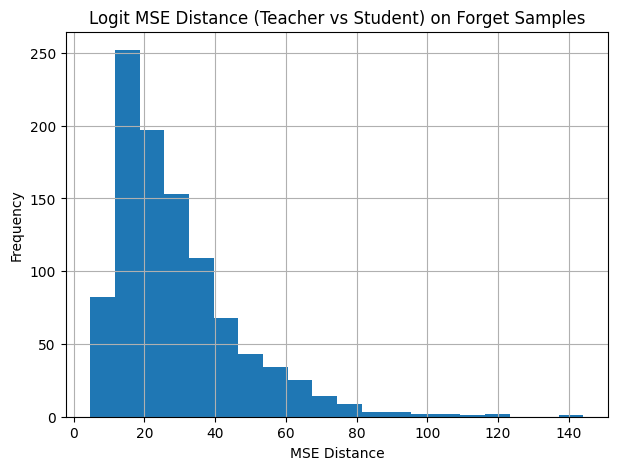

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.hist(logit_distances, bins=20)
plt.title("Logit MSE Distance (Teacher vs Student) on Forget Samples")
plt.xlabel("MSE Distance")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


### 📌 8.2 — Plot: Feature Cosine Similarity Histogram

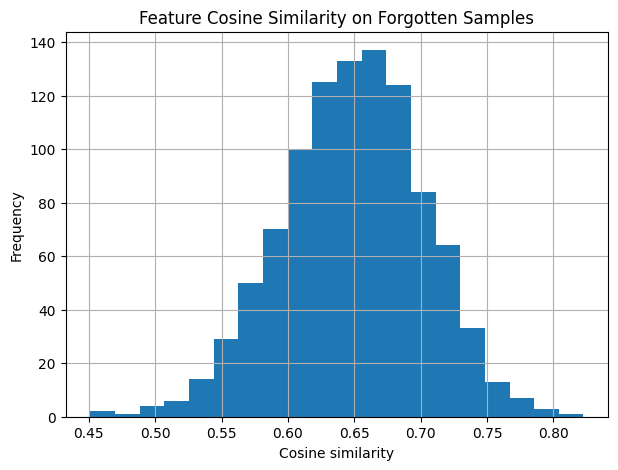

In [78]:
plt.figure(figsize=(7,5))
plt.hist(cos_sims, bins=20)
plt.title("Feature Cosine Similarity on Forgotten Samples")
plt.xlabel("Cosine similarity")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


### 📌 8.3 — Plot: Entropy Distribution on Forgotten Samples

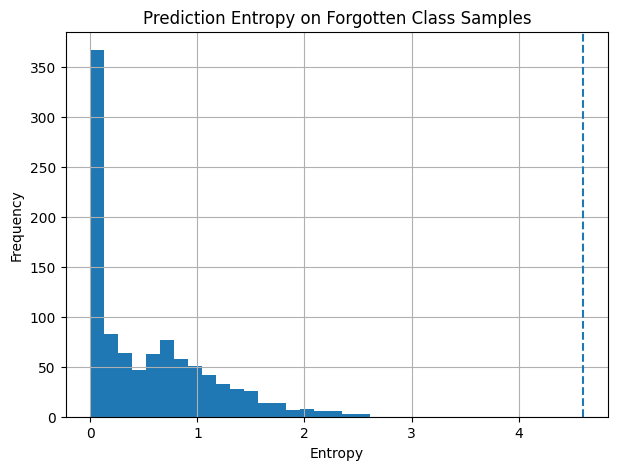

In [79]:
plt.figure(figsize=(7,5))
plt.hist(entropies, bins=20)
plt.title("Prediction Entropy on Forgotten Class Samples")
plt.xlabel("Entropy")
plt.ylabel("Frequency")
plt.axvline(np.log(len(class_names)), linestyle="--")  # mark ideal random
plt.grid(True)
plt.show()


### 📌 8.4 — Teacher vs Student Accuracy Bar Plot

Teacher Test Accuracy  : 77.87%
Student Test Accuracy  : 64.37%


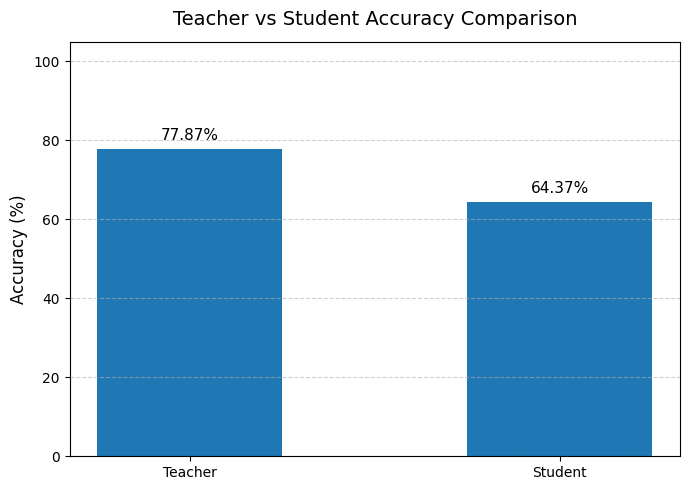

In [80]:
# 📌 Step 8.4 — Teacher vs Student Accuracy Bar Plot (Corrected)

# Compute accuracies
teacher_test_acc = evaluate(teacher_model, test_loader)
student_test_acc = evaluate(student_model, test_loader)

print(f"Teacher Test Accuracy  : {teacher_test_acc:.2f}%")
print(f"Student Test Accuracy  : {student_test_acc:.2f}%")

import matplotlib.pyplot as plt

models = ["Teacher", "Student"]
accs = [teacher_test_acc, student_test_acc]

# Create figure with better proportions
plt.figure(figsize=(7,5))

# Plot bars
bars = plt.bar(models, accs, width=0.5)

# Axes settings
plt.ylim(0, 105)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Teacher vs Student Accuracy Comparison", fontsize=14, pad=12)

# Grid (lightweight and clean)
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Add value labels above each bar
for bar, val in zip(bars, accs):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val + 1.5,
        f"{val:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

# Improve spacing
plt.tight_layout()

# Optional: save high-quality figure for paper
plt.savefig("teacher_vs_student_accuracy_clean.png", dpi=300, bbox_inches="tight")

plt.show()

## 📌 8.5 — Final Report Summary (Printout)

In [81]:
print("======================================")
print("        FINAL UNLEARNING REPORT        ")
print("======================================\n")

print("🔹 Teacher–Student Logit MSE Distance")
print(f"Mean: {logit_distances.mean():.4f}")
print(f"Std:  {logit_distances.std():.4f}\n")

print("🔹 Feature Cosine Similarity (Teacher vs Student)")
print(f"Mean: {cos_sims.mean():.4f}")
print(f"Std:  {cos_sims.std():.4f}\n")

print("🔹 Prediction Entropy on Forgotten Samples")
print(f"Mean: {entropies.mean():.4f}")
print(f"Ideal Random Guess Entropy: {np.log(len(class_names)):.4f}\n")

print("🔹 Teacher Accuracy:", teacher_test_acc)
print("🔹 Student Accuracy:", student_test_acc)

print("\n🔹 Confusion Matrix on Forgotten Samples:")
print(cm)

print("\n======================================")
print("        END OF REPORT                  ")
print("======================================")


        FINAL UNLEARNING REPORT        

🔹 Teacher–Student Logit MSE Distance
Mean: 28.9399
Std:  17.5072

🔹 Feature Cosine Similarity (Teacher vs Student)
Mean: 0.6489
Std:  0.0536

🔹 Prediction Entropy on Forgotten Samples
Mean: 0.5407
Ideal Random Guess Entropy: 4.6052

🔹 Teacher Accuracy: 77.87
🔹 Student Accuracy: 64.37

🔹 Confusion Matrix on Forgotten Samples:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 2 ... 2 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

        END OF REPORT                  


## 🔹 Step 9.1 — Imports for attack + helper functions

In [82]:
# Step 9.1 — imports & helper functions
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

device = device  # already defined in your notebook


## 🔹 Step 9.2 — Feature extractor for a model over a loader

In [83]:
# Step 9.2 — extract features (softmax probs, max_conf, entropy, topk)
def extract_features_for_loader(model, loader, topk=3):
    model.eval()
    feats = []   # list of feature vectors (numpy)
    with torch.no_grad():
        for imgs, _ in loader:
            imgs = imgs.to(device)
            logits = model(imgs)                # [B,C]
            probs = F.softmax(logits, dim=1)    # [B,C]
            max_conf, _ = probs.max(dim=1)      # [B]
            entropy = -torch.sum(probs * torch.log(probs + 1e-9), dim=1)  # [B]
            topk_vals, _ = torch.topk(probs, k=min(topk, probs.size(1)), dim=1)  # [B,topk]
            # combine into feature vector: [max_conf, entropy, topk_vals...]
            for i in range(probs.size(0)):
                vec = [float(max_conf[i].cpu()), float(entropy[i].cpu())]
                vec += [float(x.cpu()) for x in topk_vals[i]]
                feats.append(np.array(vec, dtype=np.float32))
    X = np.stack(feats, axis=0)
    return X


  ## 🔹 Step 9.3 — Build attack datasets (members vs non-members)

In [84]:
# Step 9.3 — prepare member vs non-member loaders (we already have Subset -> forget_dataset and test_forget_dataset)
# We'll create small DataLoaders with batch_size = BATCH_SIZE

from torch.utils.data import DataLoader

members_loader = DataLoader(forget_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)     # training-set forgotten samples (members)
nonmembers_loader = DataLoader(test_forget_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)  # test-set forgotten samples (non-members)

print("Members (train forgotten) samples:", len(forget_dataset))
print("Non-members (test forgotten) samples:", len(test_forget_dataset))


Members (train forgotten) samples: 5000
Non-members (test forgotten) samples: 1000


## 🔹 Step 9.4 — Extract features for teacher and student

In [85]:
# Step 9.4 — get features (teacher & student) for members and non-members
X_teach_members = extract_features_for_loader(teacher_model, members_loader)    # members under teacher
X_teach_nonmem = extract_features_for_loader(teacher_model, nonmembers_loader)  # non-members under teacher

X_stud_members = extract_features_for_loader(student_model, members_loader)     # members under student
X_stud_nonmem = extract_features_for_loader(student_model, nonmembers_loader)   # non-members under student

# create labels: members=1, non-members=0
y_members = np.ones(X_teach_members.shape[0], dtype=np.int32)
y_nonmem  = np.zeros(X_teach_nonmem.shape[0], dtype=np.int32)

print("Feature shapes (teacher):", X_teach_members.shape, X_teach_nonmem.shape)
print("Feature shapes (student):", X_stud_members.shape, X_stud_nonmem.shape)


Feature shapes (teacher): (5000, 5) (1000, 5)
Feature shapes (student): (5000, 5) (1000, 5)


## 🔹 Step 9.5 — Train attack classifier on teacher (attack_train), evaluate on teacher and student

In [86]:
# Step 9.5 — Train attack on teacher features and evaluate transfer to student

# Prepare attack train data (concatenate members + non-members)
X_attack_train = np.concatenate([X_teach_members, X_teach_nonmem], axis=0)
y_attack_train = np.concatenate([y_members, y_nonmem], axis=0)

# Shuffle + split into attack_train / attack_val for cross-eval (optional)
X_atrain, X_aval, y_atrain, y_aval = train_test_split(X_attack_train, y_attack_train, test_size=0.2, random_state=42, stratify=y_attack_train)

# scale features
scaler = StandardScaler().fit(X_atrain)
X_atrain_s = scaler.transform(X_atrain)
X_aval_s = scaler.transform(X_aval)

# fit logistic regression
attack_clf = LogisticRegression(max_iter=1000).fit(X_atrain_s, y_atrain)

# evaluate on teacher (validation portion)
y_pred_val = attack_clf.predict(X_aval_s)
y_proba_val = attack_clf.predict_proba(X_aval_s)[:,1]
acc_val = accuracy_score(y_aval, y_pred_val)
auc_val = roc_auc_score(y_aval, y_proba_val)

print("Attack (trained on teacher) — teacher-val: ACC = {:.4f}, AUC = {:.4f}".format(acc_val, auc_val))

# Now evaluate transfer: prepare student eval features (concatenate members + non-members)
X_student_eval = np.concatenate([X_stud_members, X_stud_nonmem], axis=0)
y_student_eval = np.concatenate([y_members, y_nonmem], axis=0)
X_stud_eval_s = scaler.transform(X_student_eval)  # use same scaler

y_pred_stud = attack_clf.predict(X_stud_eval_s)
y_proba_stud = attack_clf.predict_proba(X_stud_eval_s)[:,1]
acc_stud = accuracy_score(y_student_eval, y_pred_stud)
auc_stud = roc_auc_score(y_student_eval, y_proba_stud)

print("Attack (trained on teacher) — evaluate on student (transfer): ACC = {:.4f}, AUC = {:.4f}".format(acc_stud, auc_stud))


Attack (trained on teacher) — teacher-val: ACC = 0.8650, AUC = 0.6983
Attack (trained on teacher) — evaluate on student (transfer): ACC = 0.4882, AUC = 0.4990


## 🔹 Step 9.6 — (Optional) Train & evaluate attack directly on student

In [87]:
# Step 9.6 — Attack trained on student outputs
X_attack_stud = np.concatenate([X_stud_members, X_stud_nonmem], axis=0)
y_attack_stud = np.concatenate([y_members, y_nonmem], axis=0)

X_satrain, X_saval, y_satrain, y_saval = train_test_split(X_attack_stud, y_attack_stud, test_size=0.2, random_state=42, stratify=y_attack_stud)
scaler_s = StandardScaler().fit(X_satrain)
X_satrain_s = scaler_s.transform(X_satrain)
X_saval_s = scaler_s.transform(X_saval)

attack_clf_s = LogisticRegression(max_iter=1000).fit(X_satrain_s, y_satrain)

# eval on student held-out
y_pred_sval = attack_clf_s.predict(X_saval_s)
y_proba_sval = attack_clf_s.predict_proba(X_saval_s)[:,1]
acc_sval = accuracy_score(y_saval, y_pred_sval)
auc_sval = roc_auc_score(y_saval, y_proba_sval)
print("Attack (trained on student) — student-val: ACC = {:.4f}, AUC = {:.4f}".format(acc_sval, auc_sval))


Attack (trained on student) — student-val: ACC = 0.8333, AUC = 0.4758


## 🔹 Step 9.7 — Plot ROC curves (teacher-val vs student-transfer)

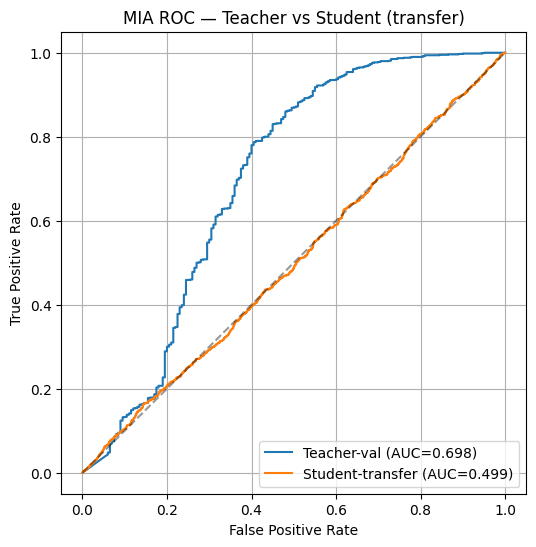

In [88]:
# Step 9.7 — ROC curves for teacher-val vs student-transfer
fpr_t, tpr_t, _ = roc_curve(y_aval, attack_clf.predict_proba(X_aval_s)[:,1])
fpr_s, tpr_s, _ = roc_curve(y_student_eval, y_proba_stud)

plt.figure(figsize=(6,6))
plt.plot(fpr_t, tpr_t, label=f'Teacher-val (AUC={auc_val:.3f})')
plt.plot(fpr_s, tpr_s, label=f'Student-transfer (AUC={auc_stud:.3f})')
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('MIA ROC — Teacher vs Student (transfer)')
plt.legend()
plt.grid(True)
plt.show()


## 🔹 Step 9.8 — Save attack results & short summary to JSON

In [89]:
# Step 9.8 — Save results
import json
attack_results = {
    "attack_trained_on_teacher_val_acc": float(acc_val),
    "attack_trained_on_teacher_val_auc": float(auc_val),
    "attack_trained_on_teacher_transfer_acc_on_student": float(acc_stud),
    "attack_trained_on_teacher_transfer_auc_on_student": float(auc_stud),
    "attack_trained_on_student_val_acc": float(acc_sval) if 'acc_sval' in locals() else None,
    "attack_trained_on_student_val_auc": float(auc_sval) if 'auc_sval' in locals() else None,
    "num_member_samples": int(X_teach_members.shape[0]),
    "num_nonmember_samples": int(X_teach_nonmem.shape[0])
}

with open("mia_results.json", "w") as f:
    json.dump(attack_results, f, indent=2)

print("Saved MIA results to mia_results.json")
print("Results summary:", attack_results)


Saved MIA results to mia_results.json
Results summary: {'attack_trained_on_teacher_val_acc': 0.865, 'attack_trained_on_teacher_val_auc': 0.6983399999999998, 'attack_trained_on_teacher_transfer_acc_on_student': 0.4881666666666667, 'attack_trained_on_teacher_transfer_auc_on_student': 0.49898980000000004, 'attack_trained_on_student_val_acc': 0.8333333333333334, 'attack_trained_on_student_val_auc': 0.47578499999999996, 'num_member_samples': 5000, 'num_nonmember_samples': 1000}
